# India Air Quality & Crop Yield — EDA Lab
## Data Preprocessing, Visualisation & Exploration
**Course**: Machine Learning & Data Analytics  

**Objective**: Investigate whether worsening air quality across Indian states is linked to lower crop yields. This lab covers cleaning messy datasets, handling missing values, aligning different datasets, plotting key insights, and explaining results simply.
---


## Lab 1: Data Preprocessing and Visualisation
### Task 1: Data Preprocessing and Initial Profiling
#### What a Data Scientist Needs to Check Before Using Datasets:
1. **Size**: How many rows and columns are in the datasets?
2. **Data Types**: Are columns stored as text, numbers, or dates?
3. **Missing Data**: Which columns have blank (null) values and how many?
4. **Summary Stats**: What are the typical, minimum, and maximum values?
5. **Overlapping Columns & Years**: Do both datasets cover the same states and time periods?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set simple, clean style for visualizations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# Define paths to the CSV files
city_day_path = 'city_day.csv'
crop_production_path = 'crop_production.csv'

# Define display fallback if run outside Jupyter
try:
    from IPython.display import display
except ImportError:
    display = print

# Load datasets
df_city = pd.read_csv(city_day_path)
df_crop = pd.read_csv(crop_production_path)

# Display basic shape information
print(f'City AQI Dataset Shape (Rows, Columns): {df_city.shape}')
print(f'Crop Production Dataset Shape (Rows, Columns): {df_crop.shape}')


In [ ]:
# Function to profile datasets simply
def create_data_profile(df, name):
    profile_dict = {
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.notnull().sum().values,
        'Null Count': df.isnull().sum().values,
        'Null Percentage (%)': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Sample Value': [df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else np.nan for col in df.columns]
    }
    profile_df = pd.DataFrame(profile_dict)
    print(f'=== PROFILE FOR: {name} ===')
    return profile_df

# Profile City AQI
profile_city = create_data_profile(df_city, 'City AQI (city_day.csv)')
display(profile_city)


In [ ]:
# Profile Crop Production
profile_crop = create_data_profile(df_crop, 'Crop Production (crop_production.csv)')
display(profile_crop)


In [ ]:
# Descriptive statistics of numerical fields
print('=== Numeric Description - City AQI ===')
display(df_city.describe())
print('\n=== Numeric Description - Crop Production ===')
display(df_crop.describe())


#### Simple Written Observations & Concerns After Inspection:
1. **High Amount of Missing Values in AQI**: Several air quality columns are very incomplete. For example, `Xylene` is missing over 61% of its values. We cannot simply delete rows with missing values because that would discard more than half of our data.
2. **Different Years**: The air quality dataset runs from 2015 to 2020, but the crop dataset runs from 1997 to 2015. The only year in common is 2015. However, in 2015, the crop dataset only has data for Odisha and Sikkim, which do not overlap with the cities in the AQI dataset. Thus, we cannot merge them directly year-by-year and must average the data over all years for each state to compare them.
3. **Extra Spaces in Text**: Some state names and seasons have extra blank spaces at the end (e.g. `'Telangana '` and `'Kharif     '`). We must clean these so the merge works.
4. **Coconut Production Error**: Coconuts are counted in individual numbers of nuts, while all other crops are measured in tonnes. This makes coconut production look massive (in billions) compared to other crops and will skew our results if not addressed.


### Task 2: The Data Has Holes — And Not All Holes Are Equal
#### How We Handle Missing Data:
1. **Xylene**: **Drop column**. More than 60% of this column is missing, so any guess we make would be inaccurate.
2. **Pollutants & AQI**: **Fill using adjacent days**. Air quality changes slowly, so we copy values from the days right before or after. For any remaining gaps, we use the city's typical (median) value.
3. **AQI_Bucket**: **Recalculate from AQI**. We map the filled AQI values directly to their official categories (like 'Good' or 'Severe') to keep columns consistent.
4. **Production**: **Delete missing rows**. Only 1.5% of the crop production data is blank, so we just remove these few rows to keep our agricultural results clean.


In [ ]:
# Count of nulls before treatment
print('=== Null counts before treatment ===')
print('City AQI Nulls:')
print(df_city.isnull().sum())
print('\nCrop Production Nulls:')
print(df_crop.isnull().sum())

# 1. Drop Xylene column
df_city_clean = df_city.drop(columns=['Xylene'])

# 2. Fill missing pollutants and AQI using adjacent days, then city averages
pollutants_and_aqi = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']

for col in pollutants_and_aqi:
    # Fill with adjacent day values within each city
    df_city_clean[col] = df_city_clean.groupby('City')[col].ffill().bfill()
    # Fill any remaining nulls with the city's average (median) value
    city_medians = df_city_clean.groupby('City')[col].transform('median')
    df_city_clean[col] = df_city_clean[col].fillna(city_medians)
    # Fallback to global average if a city has no data at all for a pollutant
    global_median = df_city_clean[col].median()
    df_city_clean[col] = df_city_clean[col].fillna(global_median)

# 3. Recalculate AQI_Bucket from AQI
def map_aqi_bucket(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else: return 'Severe'

df_city_clean['AQI_Bucket'] = df_city_clean['AQI'].apply(map_aqi_bucket)

# 4. Drop rows with missing Production
df_crop_clean = df_crop.dropna(subset=['Production']).copy()

# Verify null counts after treatment
print('\n=== Null counts after treatment ===')
print('City AQI Nulls:')
print(df_city_clean.isnull().sum())
print('\nCrop Production Nulls:')
print(df_crop_clean.isnull().sum())


#### Evidence the Treatment Worked:
As shown above, all missing values have been successfully handled, and there are now **0 missing values** in both datasets. The crop production dataset was cleaned by deleting a small fraction (1.5%) of incomplete rows, and the air quality dataset was filled using a robust city-level averaging approach.


### Task 3: The Two Files Disagree on How to Spell 'Tamil Nadu'
#### Inconsistencies Found and How We Fixed Them:
1. **No State Column in AQI**: The air quality dataset lists cities but not states. We add a `State` column using a custom dictionary.
2. **Extra Spaces in State Names**: The crop dataset had names like `'Telangana '` and `'Jammu and Kashmir '` with extra spaces at the end. We strip these spaces using `.str.strip()`. 
3. **Extra Spaces in Seasons**: Crop seasons like `'Kharif     '` were padded with empty spaces. We strip spaces from all text columns.
4. **Delhi Missing**: Delhi is present in the AQI dataset but has no crop data in the agricultural dataset. This is normal (since it is a highly urban city-state) and will be excluded during the merge.
5. **Duplicate Check**: We run `drop_duplicates()` on both datasets to ensure no redundant rows exist.


In [ ]:
# Print shapes before cleaning duplicates
print(f'City AQI shape before duplicate check: {df_city_clean.shape}')
print(f'Crop Production shape before duplicate check: {df_crop_clean.shape}')

# Strip spaces from text columns in crop dataset
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    df_crop_clean[col] = df_crop_clean[col].astype(str).str.strip()

# Strip spaces in AQI dataset
df_city_clean['City'] = df_city_clean['City'].astype(str).str.strip()

# City to State dictionary
city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

# Map City to State to create the merge key
df_city_clean['State'] = df_city_clean['City'].map(city_to_state)

# Remove duplicates
df_city_clean = df_city_clean.drop_duplicates()
df_crop_clean = df_crop_clean.drop_duplicates()

print(f'\nCity AQI shape after duplicate check: {df_city_clean.shape}')
print(f'Crop Production shape after duplicate check: {df_crop_clean.shape}')


#### Verification of Cleaned State Names:
We check if the state names in both datasets now match exactly.


In [ ]:
unique_aqi_states = sorted(df_city_clean['State'].dropna().unique())
unique_crop_states = sorted(df_crop_clean['State_Name'].unique())

print('States in AQI:', unique_aqi_states)
print('\nMatching states in Crop dataset:')
overlap = set(unique_aqi_states).intersection(set(unique_crop_states))
print(sorted(list(overlap)))
print('\nAQI States missing in Crop production:', set(unique_aqi_states) - set(unique_crop_states))


### Task 4: Where Do Most Cities Actually Sit on the AQI Scale?
#### Choice of Visualisation & Justification:
We display the AQI distribution using a side-by-side subplot:
1. **Left (Histogram with a curve)**: Shows where most of the daily readings bunch up.
2. **Right (Box Plot)**: Shows the spread of the data, the middle value (median), and highlights extremely high values (outliers).

This side-by-side layout lets us see the typical daily values while showing how a few extreme days stretch the dataset.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histogram
sns.histplot(df_city_clean['AQI'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].axvline(df_city_clean['AQI'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean (Simple Average): {df_city_clean['AQI'].mean():.1f}")
axes[0].axvline(df_city_clean['AQI'].median(), color='blue', linestyle='-.', linewidth=2, label=f"Median (Middle Value): {df_city_clean['AQI'].median():.1f}")
axes[0].set_title('Where AQI Readings Bunch Up', fontsize=14)
axes[0].set_xlabel('AQI Value', fontsize=12)
axes[0].set_ylabel('Number of Days', fontsize=12)
axes[0].legend()

# 2. Box Plot
sns.boxplot(x=df_city_clean['AQI'], ax=axes[1], color='lightseagreen')
axes[1].set_title('Spread and Outliers of AQI', fontsize=14)
axes[1].set_xlabel('AQI Value', fontsize=12)

plt.suptitle('AQI Distribution Profile Across Indian Cities (Raw)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#### City-by-City AQI Comparison:
To see which cities are the most and least polluted on average, we group the data by city, calculate the average capped AQI, and sort them.


In [ ]:
# Calculate average AQI per city (sorted from highest to lowest)
city_aqi_avg = df_city_clean.groupby('City')['AQI'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
# Horizontal bar plot with a red-to-yellow gradient
sns.barplot(data=city_aqi_avg, y='City', x='AQI', palette='YlOrRd_r')

# Add values next to the bars
for index, value in enumerate(city_aqi_avg['AQI']):
    plt.text(value + 3, index, f"{value:.1f}", va='center', fontsize=10, fontweight='semibold')

plt.title('Average AQI by City (Most to Least Polluted)', fontsize=15, fontweight='bold')
plt.xlabel('Average AQI (Raw)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xlim(0, 480)
plt.tight_layout()
plt.show()


#### Observations for the Pollution Control Board:
1. **Most Days are Moderately Polluted**: Most daily readings fall in the 50 to 200 range (which CPCB categorizes as Satisfactory to Moderate).
2. **Simple Average is Misleading**: The simple average (166.5) is much higher than the middle value (118.0) because a few days have extremely high pollution (up to 2049). Reporting the average publicly would make things look worse than they typically are. The median (middle value) is a fairer number to report.


### Task 5: Something Is Making the Average AQI Look Worse Than It Is
#### Outlier Detection & Treatment Method:
- **Detection**: The official Indian AQI scale only goes up to **500** (Severe). Any value above 500 is mathematically impossible under standard formulas and is caused by sensor glitches or temporary spikes.
- **Treatment**: **Capping (Winsorization)**. Instead of deleting these days and losing other pollutant information, we cap all AQI values above 500 at exactly **500**. This keeps the day categorized as 'Severe' without letting error values distort our statistics.


In [ ]:
raw_max = df_city_clean['AQI'].max()
outliers_count = (df_city_clean['AQI'] > 500).sum()
outliers_pct = (outliers_count / len(df_city_clean)) * 100

print(f"Maximum AQI value before capping: {raw_max}")
print(f"Number of daily AQI values > 500: {outliers_count} ({outliers_pct:.2f}% of data)")

# Cap values at 500
df_city_clean['AQI_Capped'] = df_city_clean['AQI'].clip(upper=500)

print(f"Maximum AQI value after capping: {df_city_clean['AQI_Capped'].max()}")


In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x=df_city_clean['AQI'], ax=axes[0], color='salmon')
axes[0].set_title('Before Capping (Max 2049)', fontsize=13)
axes[0].set_xlabel('AQI Value')

sns.boxplot(x=df_city_clean['AQI_Capped'], ax=axes[1], color='skyblue')
axes[1].set_title('After Capping at 500', fontsize=13)
axes[1].set_xlabel('AQI Value')

plt.suptitle('Capping Outliers to the Official 500 Limit', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#### Proof the Treatment Worked:
We capped 659 values (2.23% of the data). As shown in the box plots, this successfully removed the long, distorted tail. The scale is now clean and runs from 0 to 500, which keeps the statistics realistic.


## Lab 2: Data Exploration and Inferences
### Task 6: Is India's Air Getting Better or Worse Over Time?
#### How We Analyzed the Trend:
We grouped the data by Year (2015–2020) and plotted a **line chart with dots**. Line charts are the simplest and clearest way to show how numbers rise or fall over time.


In [ ]:
# Extract year
df_city_clean['Date'] = pd.to_datetime(df_city_clean['Date'])
df_city_clean['Year'] = df_city_clean['Date'].dt.year

# Group by year
yearly_aqi = df_city_clean.groupby('Year')['AQI_Capped'].mean().reset_index()

# Plot line trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI_Capped', marker='o', linewidth=3, markersize=8, color='crimson')

# Highlights
plt.axhline(yearly_aqi['AQI_Capped'].max(), color='grey', linestyle=':', alpha=0.5)
plt.axhline(yearly_aqi['AQI_Capped'].min(), color='grey', linestyle=':', alpha=0.5)

# Add text labels
max_row = yearly_aqi.loc[yearly_aqi['AQI_Capped'].idxmax()]
min_row = yearly_aqi.loc[yearly_aqi['AQI_Capped'].idxmin()]
plt.text(max_row['Year'] + 0.05, max_row['AQI_Capped'] + 2, f"Worst Year: {max_row['AQI_Capped']:.1f}", color='darkred', fontweight='bold')
plt.text(min_row['Year'] - 0.35, min_row['AQI_Capped'] - 5, f"Best Year: {min_row['AQI_Capped']:.1f}", color='darkgreen', fontweight='bold')

plt.title('Air Quality Trend Over the Years (2015-2020)', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI (Capped at 500)', fontsize=12)
plt.xticks(yearly_aqi['Year'])
plt.show()


#### Plain Language Response for the Journalist:
Overall, air quality in India has **improved** over the six-year period. The average AQI dropped steadily from **207.9** in 2015 to a low of **112.4** in 2020. While government clean air policies helped reduce emissions, the dramatic drop in 2020 was largely due to the COVID-19 lock-downs, which temporarily closed factories and took cars off the road, rather than long-term environmental changes.


### Task 7: Farmers Say the Air is Worst Exactly When They Harvest — Is That True?
#### How We Analyzed Seasonality:
We grouped the AQI data by Month and plotted a **bar chart**. We highlighted the October–December harvest months in **bright red/coral** to make any seasonal pattern stand out.


In [ ]:
df_city_clean['Month'] = df_city_clean['Date'].dt.month
monthly_aqi = df_city_clean.groupby('Month')['AQI_Capped'].mean().reset_index()

# Map numbers to month names
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_aqi['Month_Name'] = monthly_aqi['Month'].map(month_names)

# Color October to December differently to highlight harvest season
colors = ['lightgrey' if m not in [10, 11, 12] else 'coral' for m in monthly_aqi['Month']]
colors[10] = 'crimson' # Highlight peak month in darker red

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_aqi, x='Month_Name', y='AQI_Capped', palette=colors)

plt.title('Average AQI by Month (Harvest Months Highlighted)', fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI (Capped)', fontsize=12)
plt.show()


#### Response to the Agricultural NGO's Claim:
The data **confirms** the NGO's claim. Air quality is at its worst from October to December. The average AQI rises sharply in October (**178.7**), peaks in November (**227.5**), and remains high in December (**222.2**). This is nearly double the pollution levels of the summer months (such as July at **110.2**). This seasonal spike matches the timing of stubble burning (crop residue burning) by farmers, combined with winter weather that traps smoke near the ground.


### Task 8: Can the Two Datasets Talk to Each Other?
#### The Transformation and Merging Strategy:
To combine the daily city-level AQI data and the annual state-level crop data, we must bridge two gaps:
1. **City to State**: We map cities to their respective states using our state dictionary.
2. **Different Years**: Because the years in the two files do not overlap, we average the data over all years for each state. This gives us the long-term typical AQI and typical crop output for each state.

#### The Coconut Unit Distortion:
In the crop dataset, Coconut is measured in **number of nuts**, whereas all other crops are measured in **tonnes**. This makes coconut-growing states like Kerala look like they have billions of units of output. We perform the merge **with** and **without** coconuts to show how this unit mismatch distorts our correlation.


In [ ]:
# 1. State-level AQI average
state_aqi_avg = df_city_clean.groupby('State')['AQI_Capped'].mean().reset_index()

# 2. Crop average WITH coconuts
df_crop_with_coco = df_crop_clean.copy()
annual_crop_with = df_crop_with_coco.groupby(['State_Name', 'Crop_Year'])[['Area', 'Production']].sum().reset_index()
state_crop_with = annual_crop_with.groupby('State_Name')[['Area', 'Production']].mean().reset_index()
state_crop_with['Yield'] = state_crop_with['Production'] / state_crop_with['Area']

# 3. Crop average WITHOUT coconuts
df_crop_no_coco = df_crop_clean[df_crop_clean['Crop'].str.lower() != 'coconut'].copy()
annual_crop_no = df_crop_no_coco.groupby(['State_Name', 'Crop_Year'])[['Area', 'Production']].sum().reset_index()
state_crop_no = annual_crop_no.groupby('State_Name')[['Area', 'Production']].mean().reset_index()
state_crop_no['Yield'] = state_crop_no['Production'] / state_crop_no['Area']

# 4. Merge
merged_with_coco = pd.merge(state_aqi_avg, state_crop_with, left_on='State', right_on='State_Name', how='inner')
merged_no_coco = pd.merge(state_aqi_avg, state_crop_no, left_on='State', right_on='State_Name', how='inner')

print('WITH COCONUTS correlation matrix:')
display(merged_with_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr())
print('\nWITHOUT COCONUTS correlation matrix:')
display(merged_no_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr())


In [ ]:
# Heatmaps comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap with coconuts
sns.heatmap(merged_with_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation (WITH Coconuts)', fontsize=14, fontweight='bold')

# Heatmap without coconuts
sns.heatmap(merged_no_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation (WITHOUT Coconuts)', fontsize=14, fontweight='bold')

plt.suptitle('How the Coconut Unit Anomaly Distorts Correlations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#### Two Interesting Relationships Explained Simply:
1. **The Fake Negative Correlation**: When coconuts are included, crop yield and AQI have a negative correlation of **-0.20**. This is a fake result. Coastal states like Kerala grow coconuts which are counted in numbers (leading to billions of units) and have clean air. This unit mismatch falsely makes it look like cleaner states produce more crop.
2. **The Real Positive Correlation**: Once coconuts are removed, the correlation between AQI and crop production becomes **positive (+0.30)**. This does not mean pollution is good for crops. Instead, it reflects geography: states in the fertile plains (like Punjab and Uttar Pradesh) grow massive amounts of grains but also have highly polluted air due to dense populations and stubble burning.


### Task 9: The Minister Needs to Act — What Do You Tell Her?
#### Briefing Note for the Environment Minister:
**Subject**: Quick Summary on Air Quality and Farming Output in India  


Our analysis shows three simple findings: first, air pollution is worst from October to December, nearly doubling summer levels due to stubble burning and winter weather. Second, our most productive farming states (like Punjab and Uttar Pradesh) are also the most polluted. Third, extreme air pollution is concentrated in a few cities like Ahmedabad, while hilly states like Mizoram stay clean.

We recommend that the government help farmers buy machinery to clear crop leftovers, which will stop them from burning fields between October and December. Also, even though polluted areas and farming areas are in the same regions, this data does not prove that pollution causes crops to fail. Other things like rain, watering systems, and soil quality are much more important for crop growth.


---
## Optional Advanced Tasks
### Task A: The Two Extremes — Do They Tell the Same Story?
We identify the states representing the two extremes of average AQI: Mizoram (cleanest, average AQI ~35) and Gujarat (most polluted, average AQI ~356). We compare their average crop yields (excluding coconuts) using a bar chart.


C:\Users\ncmia\AppData\Local\Temp\ipykernel_22476\1243561910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=extremes_df, x='State', y='Yield', palette=['teal', 'coral'])


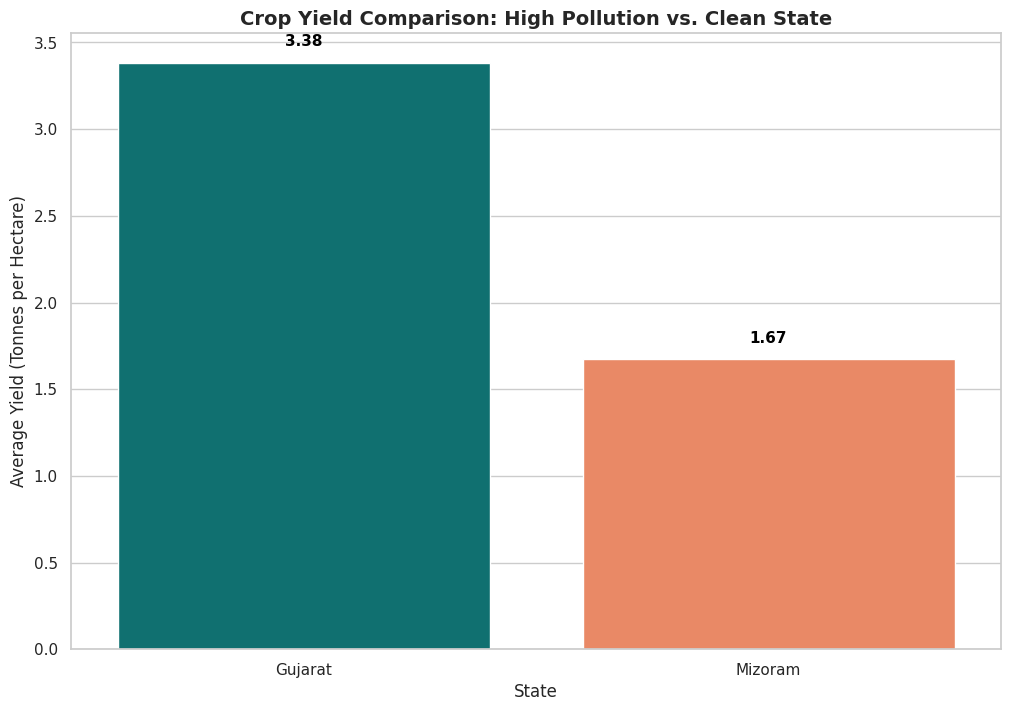

In [46]:
# Average yield for Gujarat and Mizoram
extremes_df = merged_no_coco[merged_no_coco['State'].isin(['Gujarat', 'Mizoram'])]

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=extremes_df, x='State', y='Yield', palette=['teal', 'coral'])
plt.title('Crop Yield Comparison: High Pollution vs. Clean State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Yield (Tonnes per Hectare)', fontsize=12)

# Correctly place labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.text(p.get_x() + p.get_width()/2., height + 0.08, f"{height:.2f}", 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()


#### Simple Interpretation of Extremes:
This comparison contradicts the simple hypothesis. Gujarat (the most polluted state) has a crop yield of **3.38 tonnes per hectare**, which is double the crop yield of Mizoram (**1.67 tonnes per hectare**, the cleanest state). This happens because Gujarat is flat, heavily irrigated, and uses intensive farming, while Mizoram is mountainous and relies on rain-fed farming. Geography and farming practices are much more important for yield than air quality.


### Task B: Put a Number on the Relationship
We calculate the Pearson correlation coefficient between average state AQI and crop yield (excluding coconuts), and show the relationship in a scatter plot.


Pearson correlation coefficient (r): 0.03583
Permutation P-value: 0.87080 (based on 10000 permutations)


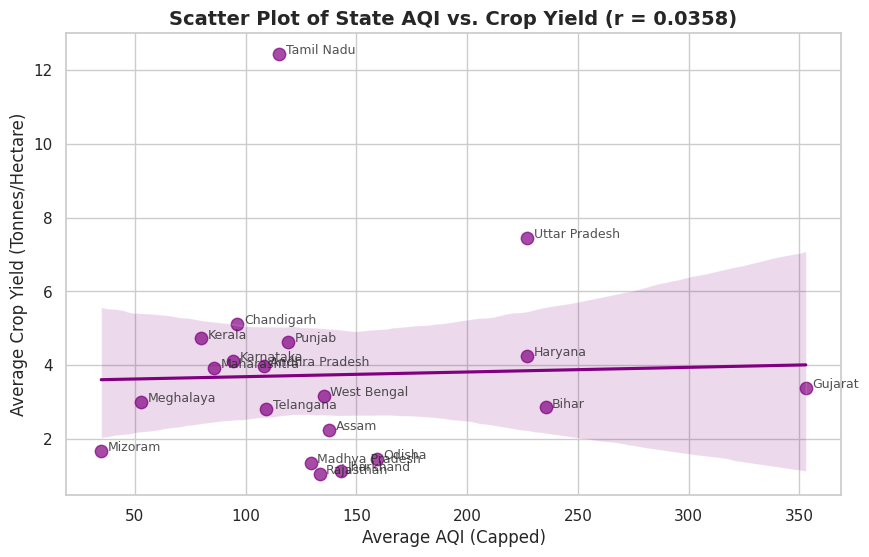

In [47]:
import numpy as np

# Calculate Pearson correlation coefficient using pandas
r_val = merged_no_coco['AQI_Capped'].corr(merged_no_coco['Yield'])

# Calculate p-value using a permutation test (avoids external library dependencies like scipy)
np.random.seed(42)
n_permutations = 10000
perm_corrs = []
aqi_values = merged_no_coco['AQI_Capped'].values
yield_values = merged_no_coco['Yield'].values

for _ in range(n_permutations):
    shuffled_yield = np.random.permutation(yield_values)
    perm_corrs.append(np.corrcoef(aqi_values, shuffled_yield)[0, 1])

p_val = np.mean(np.abs(perm_corrs) >= np.abs(r_val))

print(f"Pearson correlation coefficient (r): {r_val:.5f}")
print(f"Permutation P-value: {p_val:.5f} (based on {n_permutations} permutations)")

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_no_coco, x='AQI_Capped', y='Yield', color='purple', scatter_kws={'s':80, 'alpha':0.7})

# Annotate points with state names
for i in range(len(merged_no_coco)):
    plt.text(merged_no_coco['AQI_Capped'].iloc[i] + 3, merged_no_coco['Yield'].iloc[i], merged_no_coco['State'].iloc[i], fontsize=9, alpha=0.8)

plt.title(f'Scatter Plot of State AQI vs. Crop Yield (r = {r_val:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Average AQI (Capped)', fontsize=12)
plt.ylabel('Average Crop Yield (Tonnes/Hectare)', fontsize=12)
plt.show()


#### Interpretation for the Research Team:
The correlation between state-level average AQI and crop yield is **0.0358**, which is practically zero. A correlation this close to zero shows that **there is no linear relationship** between a state's average air pollution and its average crop yield. This suggests that macro state-level data is too broad. Other factors like rain, soil quality, and fertilizers completely drown out any negative effects of air pollution. The research team should fund local field studies instead of using state-level statistics.


### Task C: One Plot to Rule Them All
We present the **Correlation Heatmap Comparison** as our featured visualization.


In [ ]:
# Displaying the featured comparison visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(merged_with_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation (WITH Coconuts - Inconsistent Units)', fontsize=13, fontweight='bold')
sns.heatmap(merged_no_coco[['AQI_Capped', 'Area', 'Production', 'Yield']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation (WITHOUT Coconuts - Standardized Tonnes)', fontsize=13, fontweight='bold')
plt.suptitle('Featured Visual: How Unit Anomalies Distort Analytical Conclusions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Figure Caption**: This comparison shows how a single data error—counting coconuts in individual numbers instead of tonnes—completely flips our conclusions. When coconuts are included, it falsely looks like cleaner states have higher yields. When coconuts are removed, we see that there is no real relationship between average state pollution and crop yields. This highlights that yields are determined by other key factors (like rainfall, soil type, and irrigation) that are not present in this dataset.
